In [95]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df=pd.read_csv('Epileptic Seizure Recognition.csv')
df.head()

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [41]:
df.shape


(11500, 180)

In [42]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


**Convert into Binary Classification**
- filter seizure from non siezure

In [44]:
df['target'] = df['y'].apply(lambda x: 1 if x == 1 else 0)

print(df['target'].value_counts())

target
0    9200
1    2300
Name: count, dtype: int64


In [48]:
df['target'][:5]

0    0
1    1
2    0
3    0
4    0
Name: target, dtype: int64

**Class Distribution**

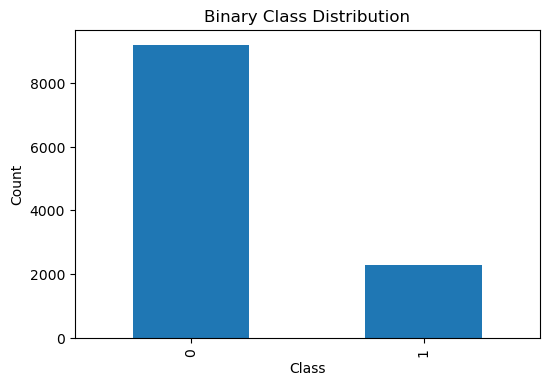

In [46]:
plt.figure(figsize=(6,4))

df['target'].value_counts().plot(kind='bar')

plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

**Split Features and Target**

In [57]:
print(df.columns)

Index(['Unnamed', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178', 'y',
       'target'],
      dtype='object', length=181)


In [62]:
df = df.drop(columns=['Unnamed'])

In [63]:
X = df.drop(columns=['y', 'target'])

y = df['target']

print(X.shape)
print(y.shape)

(11500, 178)
(11500,)


**Train Test Split**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(9200, 178)
(2300, 178)


**Create Evaluation Function**

In [65]:
def evaluate_model(name, model):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    pr_auc = average_precision_score(y_test, y_prob)

    print("\n", "-"*60)
    print(name)
    print("-"*60)

    print("Accuracy :", round(acc,4))
    print("F1-Score :", round(f1,4))
    print("PR-AUC   :", round(pr_auc,4))

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm)

    disp.plot(cmap='Blues')

    plt.title(name)

    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(6,4))

    plt.plot(recall, precision)

    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.title(f"Precision Recall Curve - {name}")

    plt.show()

    return {
        'Model': name,
        'Accuracy': acc,
        'F1-score': f1,
        'PR-AUC': pr_auc
    }

### Pipeline A:
- Normalization > Noise removal > Feature selection

In [93]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

In [67]:
class NoiseRemoval(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = pd.DataFrame(X).copy()

        for col in X.columns:

            lower = X[col].quantile(0.01)
            upper = X[col].quantile(0.99)

            X[col] = np.clip(X[col], lower, upper)

        return X.values

### Pipeline B
- Feature extraction > Scaling > PCA
- mean:std:min:max:range...... from EEG features.

In [68]:
class FeatureExtraction(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = pd.DataFrame(X)

        extracted = pd.DataFrame()

        extracted['mean'] = X.mean(axis=1)

        extracted['std'] = X.std(axis=1)

        extracted['min'] = X.min(axis=1)

        extracted['max'] = X.max(axis=1)

        extracted['range'] = extracted['max'] - extracted['min']

        return extracted.values

In [69]:
print(X_train.dtypes)

X1      int64
X2      int64
X3      int64
X4      int64
X5      int64
        ...  
X174    int64
X175    int64
X176    int64
X177    int64
X178    int64
Length: 178, dtype: object


**PIPELINE A**
- Normalization : Noise Removal : Feature Selection


 ------------------------------------------------------------
Pipeline A: Normalization → Noise Removal → Feature Selection
------------------------------------------------------------
Accuracy : 0.8017
F1-Score : 0.0172
PR-AUC   : 0.4886

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1840
           1       1.00      0.01      0.02       460

    accuracy                           0.80      2300
   macro avg       0.90      0.50      0.45      2300
weighted avg       0.84      0.80      0.72      2300



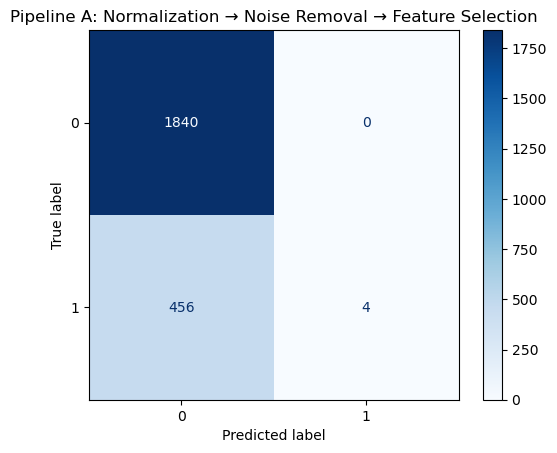

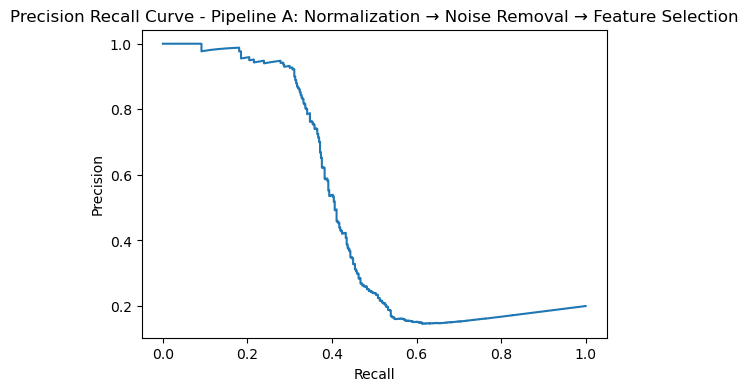

In [70]:
pipeline_a = Pipeline([

    ('normalization', MinMaxScaler()),

    ('noise_removal', NoiseRemoval()),

    ('feature_selection', SelectKBest(
        score_func=mutual_info_classif,
        k=40
    )),

    ('classifier', LogisticRegression(
        max_iter=5000,
        solver='liblinear'
    ))

])

result_a = evaluate_model(
    "Pipeline A: Normalization → Noise Removal → Feature Selection",
    pipeline_a
)



Pipeline A first normalizes all EEG features into the same range. Then noise removal reduces extreme EEG spikes and outliers. After that, feature selection keeps only the most informative features before logistic regression training.

This pipeline focuses on cleaning the original EEG features before classification.

----------

### PIPELINE B
- Feature Extraction > Scaling > PCA


 ------------------------------------------------------------
Pipeline B: Feature Extraction → Scaling → PCA
------------------------------------------------------------
Accuracy : 0.9513
F1-Score : 0.8713
PR-AUC   : 0.94

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1840
           1       0.92      0.82      0.87       460

    accuracy                           0.95      2300
   macro avg       0.94      0.90      0.92      2300
weighted avg       0.95      0.95      0.95      2300



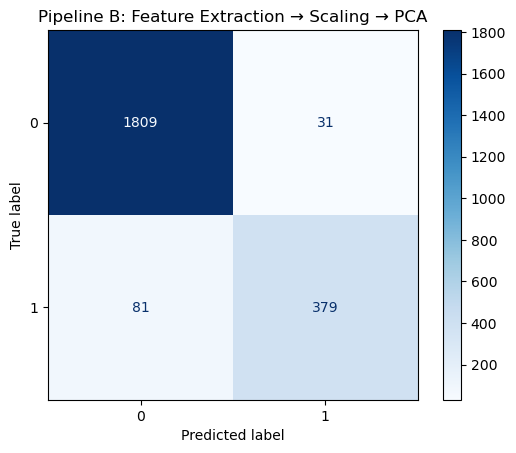

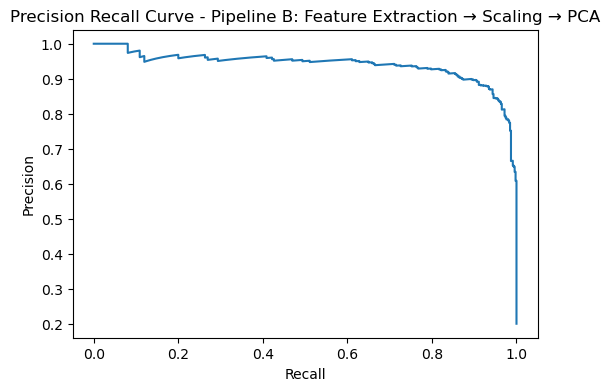

In [71]:
pipeline_b = Pipeline([

    ('feature_extraction', FeatureExtraction()),

    ('scaling', StandardScaler()),

    ('pca', PCA(n_components=0.95)),

    ('classifier', LogisticRegression(
        max_iter=5000
    ))

])

result_b = evaluate_model(
    "Pipeline B: Feature Extraction → Scaling → PCA",
    pipeline_b
)



Pipeline B first extracts statistical EEG characteristics such as mean, standard deviation, minimum, maximum, and range. Then scaling standardizes the extracted features. PCA reduces dimensionality while preserving most variance.

This pipeline focuses on generating compact higher-level EEG representations

**Compare Both Pipelines**

In [72]:
comparison_df = pd.DataFrame([result_a, result_b])

comparison_df

,Model,Accuracy,F1-score,PR-AUC
0,Pipeline A: Normalization → Noise Removal → Fe...,0.801739,0.017241,0.488558
1,Pipeline B: Feature Extraction → Scaling → PCA,0.951304,0.871264,0.939994


here we can observe that overall pipeline b work best as compared to pipeline a

--------

### Baseline Logistic Regression

In [94]:
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression



from sklearn.metrics import (
    accuracy_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)



 ------------------------------------------------------------
Baseline Logistic Regression
------------------------------------------------------------
Accuracy : 0.8161
F1-Score : 0.1557
PR-AUC   : 0.431

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1840
           1       0.95      0.08      0.16       460

    accuracy                           0.82      2300
   macro avg       0.88      0.54      0.53      2300
weighted avg       0.84      0.82      0.75      2300



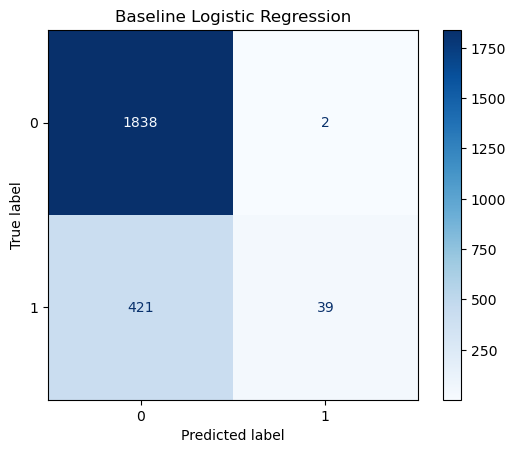

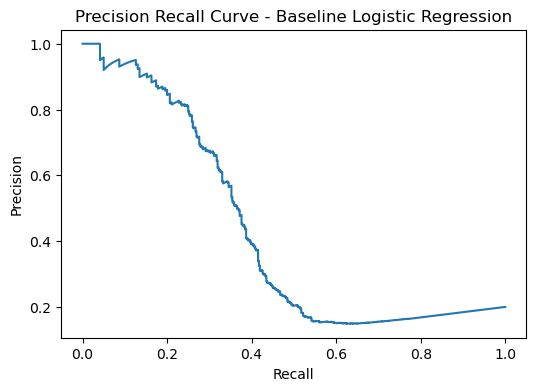

In [73]:
baseline_model = Pipeline([

    ('scaler', StandardScaler()),

    ('classifier', LogisticRegression(
        max_iter=5000
    ))

])

baseline_result = evaluate_model(
    "Baseline Logistic Regression",
    baseline_model
)

**Underfitting Demonstration**


 ------------------------------------------------------------
Underfitting Model
------------------------------------------------------------
Accuracy : 0.8
F1-Score : 0.0
PR-AUC   : 0.4599

Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1840
           1       0.00      0.00      0.00       460

    accuracy                           0.80      2300
   macro avg       0.40      0.50      0.44      2300
weighted avg       0.64      0.80      0.71      2300



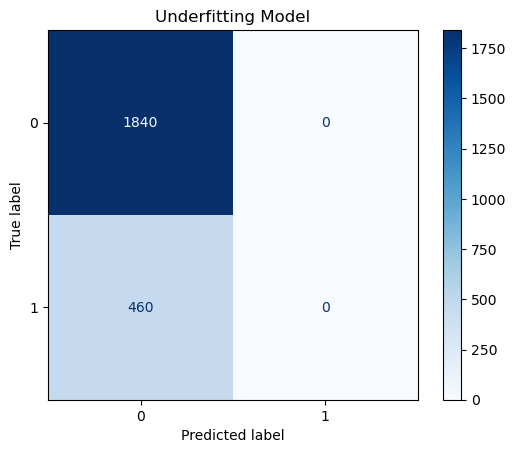

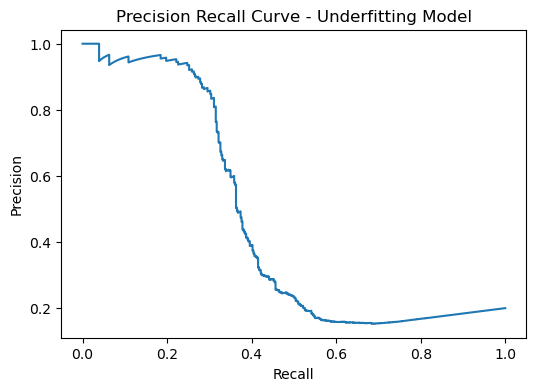

In [74]:
underfit_model = Pipeline([

    ('scaler', StandardScaler()),

    ('feature_selection', SelectKBest(
        score_func=mutual_info_classif,
        k=5
    )),

    ('classifier', LogisticRegression(
        C=0.0001,
        penalty='l2',
        max_iter=5000
    ))

])

underfit_result = evaluate_model(
    "Underfitting Model",
    underfit_model
)

This model underfits because:

Too few features are used
Strong regularisation prevents learning complex patterns

Underfitting usually causes poor training and testing performance.mmm

**Overfitting Demonstration**


 ------------------------------------------------------------
Overfitting Model
------------------------------------------------------------
Accuracy : 0.9504
F1-Score : 0.8699
PR-AUC   : 0.9041

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1840
           1       0.92      0.83      0.87       460

    accuracy                           0.95      2300
   macro avg       0.94      0.90      0.92      2300
weighted avg       0.95      0.95      0.95      2300



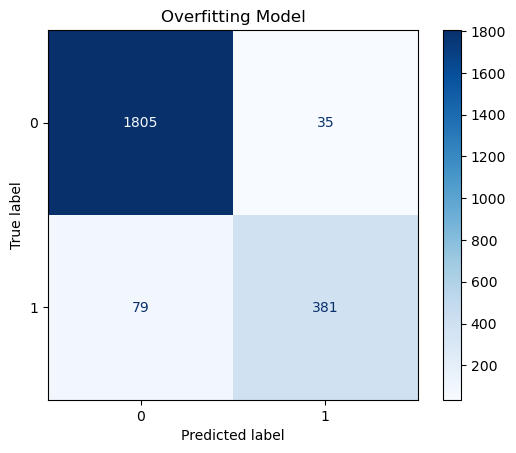

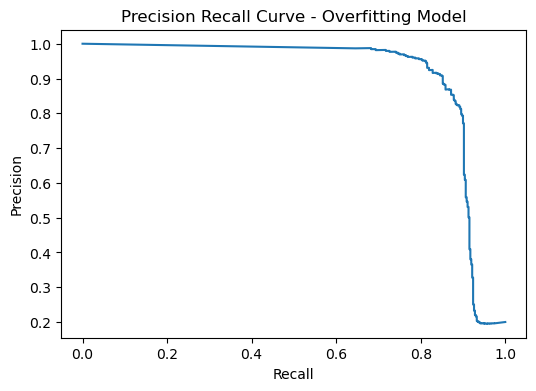

In [75]:
from sklearn.preprocessing import PolynomialFeatures

overfit_model = Pipeline([

    ('scaler', StandardScaler()),

    ('poly', PolynomialFeatures(
        degree=2,
        include_bias=False
    )),

    ('classifier', LogisticRegression(
        penalty=None,
        max_iter=10000
    ))

])

overfit_result = evaluate_model(
    "Overfitting Model",
    overfit_model
)


This model becomes overly complex because polynomial features dramatically increase dimensionality while no regularisation is applied.

Overfitting means:

Training performance becomes very high
Generalisation performance becomes weak

____________

**Learning Curves**

In [76]:
def plot_learning_curve(model, title):

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring='f1',
        train_sizes=np.linspace(0.1,1.0,5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)

    val_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(7,5))

    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')

    plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

    plt.xlabel("Training Samples")

    plt.ylabel("F1 Score")

    plt.title(title)

    plt.legend()

    plt.show()

**Plot Curves**

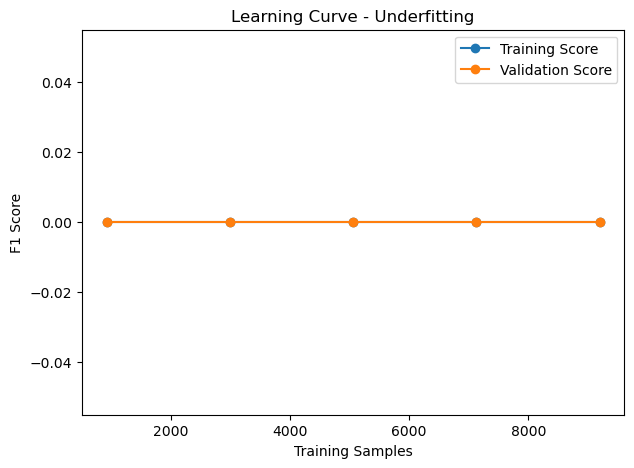

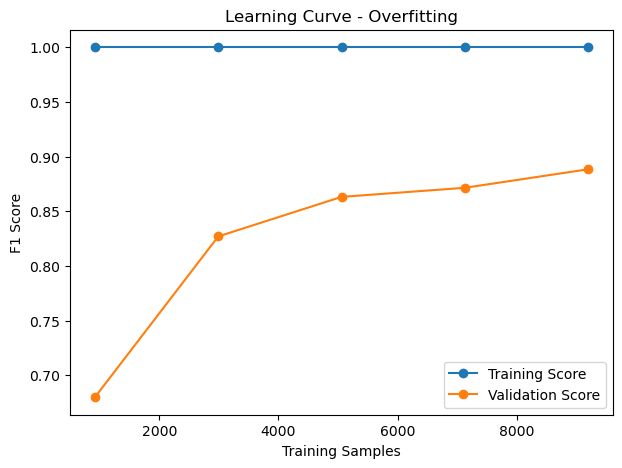

In [77]:
plot_learning_curve(
    underfit_model,
    "Learning Curve - Underfitting"
)

plot_learning_curve(
    overfit_model,
    "Learning Curve - Overfitting"
)

Interpretation
Underfitting:
both curves low
model cannot learn enough
Overfitting:
training score very high
validation score much lower

This demonstrates poor generalisatio

------

### L1 vs L2 vs Elastic Net

In [78]:
regularization_results = []

**L1 Regularisation**


 ------------------------------------------------------------
L1 Regularisation
------------------------------------------------------------
Accuracy : 0.8143
F1-Score : 0.1374
PR-AUC   : 0.4456

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1840
           1       0.97      0.07      0.14       460

    accuracy                           0.81      2300
   macro avg       0.89      0.54      0.52      2300
weighted avg       0.84      0.81      0.74      2300



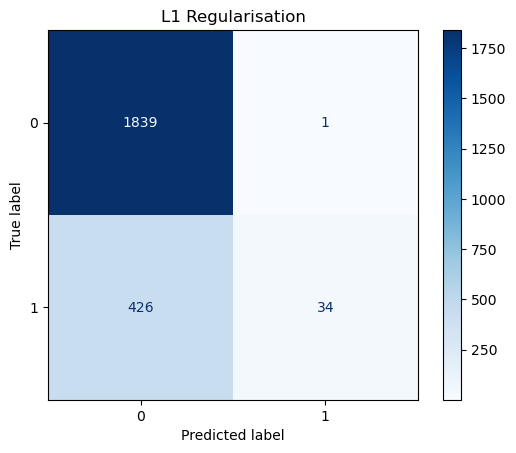

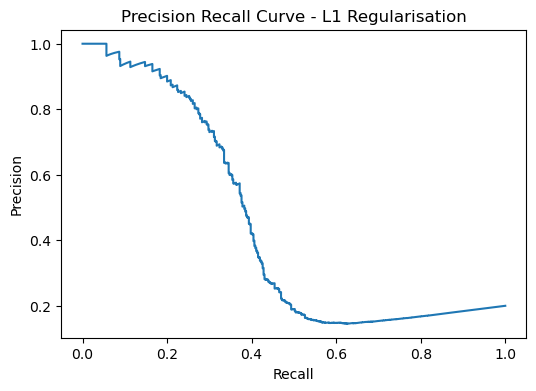

In [79]:
l1_model = Pipeline([

    ('scaler', StandardScaler()),

    ('classifier', LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1,
        max_iter=1000
    ))

])

l1_result = evaluate_model(
    "L1 Regularisation",
    l1_model
)

regularization_results.append(l1_result)

**L2 Regularisation**


 ------------------------------------------------------------
L2 Regularisation
------------------------------------------------------------
Accuracy : 0.8161
F1-Score : 0.1557
PR-AUC   : 0.431

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1840
           1       0.95      0.08      0.16       460

    accuracy                           0.82      2300
   macro avg       0.88      0.54      0.53      2300
weighted avg       0.84      0.82      0.75      2300



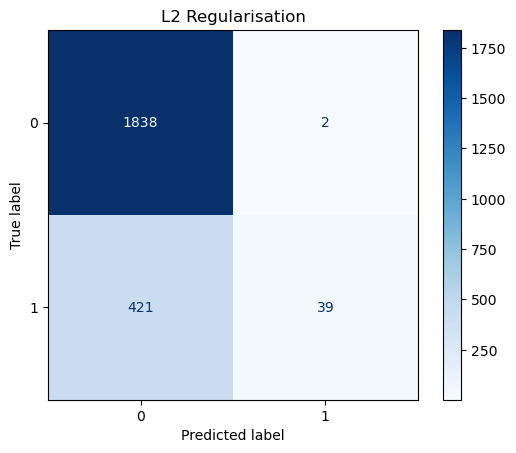

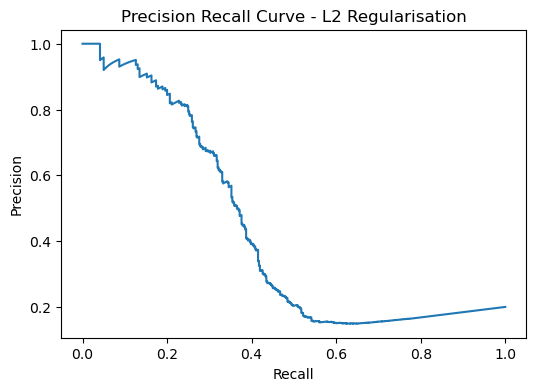

In [80]:
l2_model = Pipeline([

    ('scaler', StandardScaler()),

    ('classifier', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        C=1,
        max_iter=1000
    ))

])

l2_result = evaluate_model(
    "L2 Regularisation",
    l2_model
)

regularization_results.append(l2_result)

 **Elastic Net**


 ------------------------------------------------------------
Elastic Net
------------------------------------------------------------
Accuracy : 0.8152
F1-Score : 0.1483
PR-AUC   : 0.4449

Classification Report:

              precision    recall  f1-score   support

           0       0.81      1.00      0.90      1840
           1       0.95      0.08      0.15       460

    accuracy                           0.82      2300
   macro avg       0.88      0.54      0.52      2300
weighted avg       0.84      0.82      0.75      2300



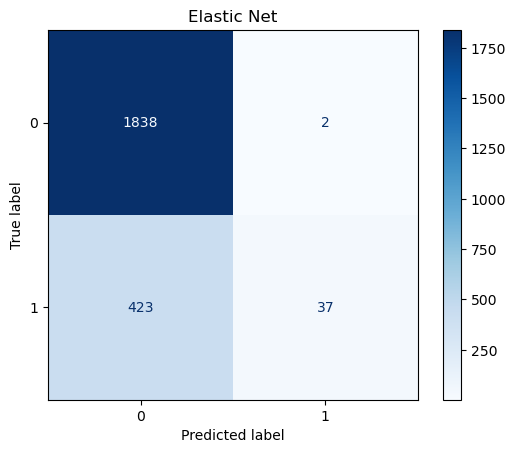

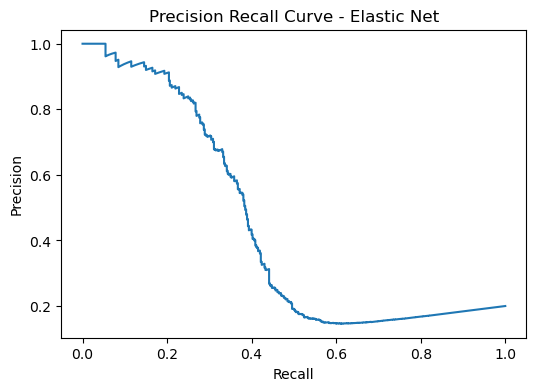

In [81]:
elastic_model = Pipeline([

    ('scaler', StandardScaler()),

    ('classifier', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        l1_ratio=0.5,
        C=1,
        max_iter=1000
    ))

])

elastic_result = evaluate_model(
    "Elastic Net",
    elastic_model
)

regularization_results.append(elastic_result)

**Compare Regularisation**

In [82]:
reg_df = pd.DataFrame(regularization_results)

reg_df

,Model,Accuracy,F1-score,PR-AUC
0,L1 Regularisation,0.814348,0.137374,0.445644
1,L2 Regularisation,0.816087,0.155689,0.431024
2,Elastic Net,0.815217,0.148297,0.444851


L1 produces sparse models by forcing some coefficients to zero
L2 keeps all features but reduces coefficient magnitude
Elastic Net combines both approaches

The best regularisation method is the one with stronger generalisation and higher PR-AUC.

**Sparsity Analysis**

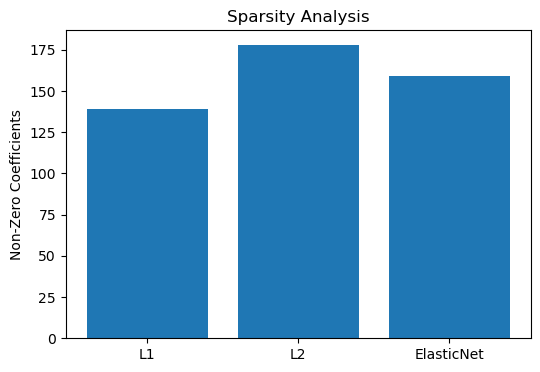

In [83]:
models = {
    'L1': l1_model,
    'L2': l2_model,
    'ElasticNet': elastic_model
}

non_zero_features = []

for name, model in models.items():

    model.fit(X_train, y_train)

    coef = model.named_steps['classifier'].coef_[0]

    non_zero = np.sum(coef != 0)

    non_zero_features.append(non_zero)

plt.figure(figsize=(6,4))

plt.bar(models.keys(), non_zero_features)

plt.ylabel("Non-Zero Coefficients")

plt.title("Sparsity Analysis")

plt.show()

## Class Imbalance Handling
- SMOTE
- Undersampling
- Class weighting

In [91]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

**SMOTE Oversampling**


 ------------------------------------------------------------
SMOTE Oversampling
------------------------------------------------------------
Accuracy : 0.6957
F1-Score : 0.3625
PR-AUC   : 0.4132

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1840
           1       0.31      0.43      0.36       460

    accuracy                           0.70      2300
   macro avg       0.58      0.60      0.58      2300
weighted avg       0.74      0.70      0.71      2300



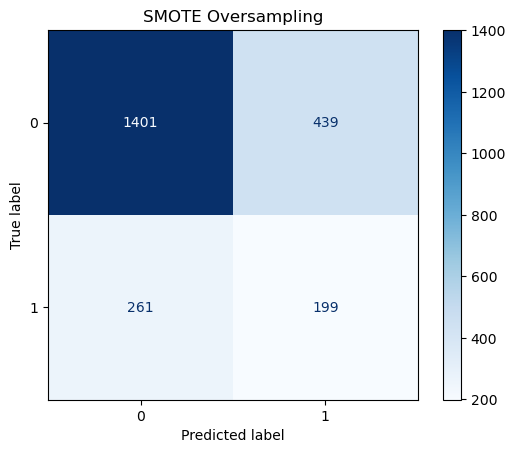

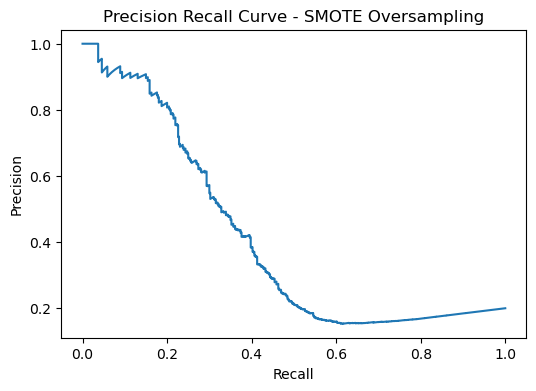

In [84]:
smote_model = ImbPipeline([

    ('scaler', StandardScaler()),

    ('smote', SMOTE(random_state=42)),

    ('classifier', LogisticRegression(
        max_iter=5000
    ))

])

smote_result = evaluate_model(
    "SMOTE Oversampling",
    smote_model
)

**Random Undersampling**


 ------------------------------------------------------------
Random Undersampling
------------------------------------------------------------
Accuracy : 0.6791
F1-Score : 0.3339
PR-AUC   : 0.3928

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.75      0.79      1840
           1       0.29      0.40      0.33       460

    accuracy                           0.68      2300
   macro avg       0.56      0.58      0.56      2300
weighted avg       0.72      0.68      0.70      2300



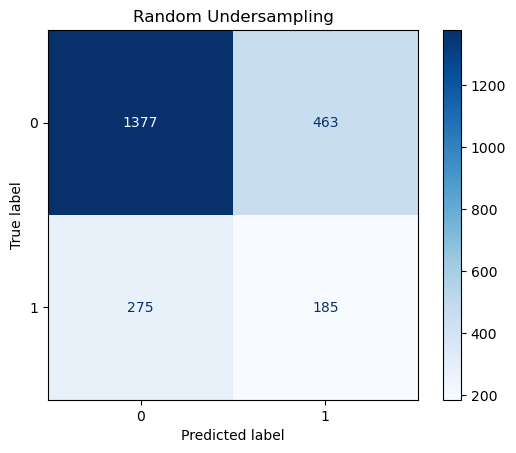

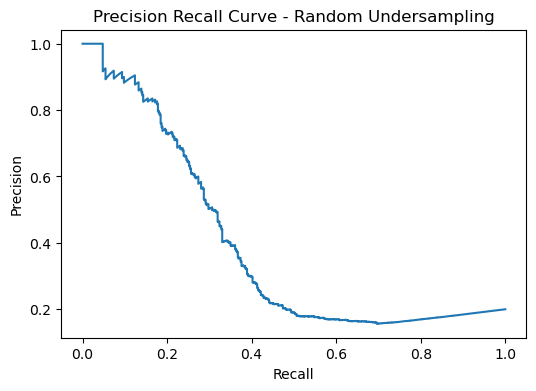

In [85]:
under_model = ImbPipeline([

    ('scaler', StandardScaler()),

    ('under', RandomUnderSampler(random_state=42)),

    ('classifier', LogisticRegression(
        max_iter=5000
    ))

])

under_result = evaluate_model(
    "Random Undersampling",
    under_model
)

**Class Weighting**


 ------------------------------------------------------------
Class Weighting
------------------------------------------------------------
Accuracy : 0.7057
F1-Score : 0.3484
PR-AUC   : 0.3977

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      1840
           1       0.31      0.39      0.35       460

    accuracy                           0.71      2300
   macro avg       0.58      0.59      0.58      2300
weighted avg       0.73      0.71      0.72      2300



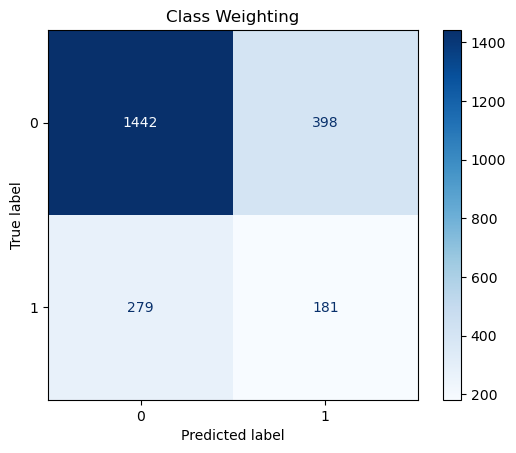

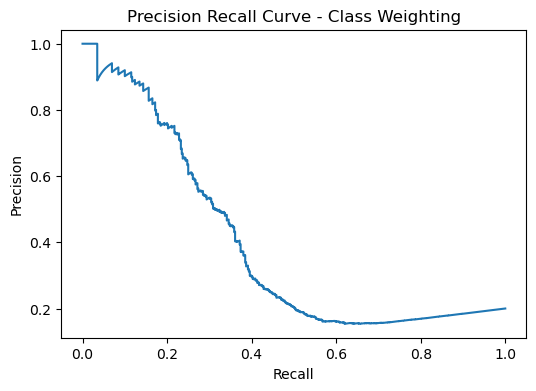

In [86]:
weight_model = Pipeline([

    ('scaler', StandardScaler()),

    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=5000
    ))

])

weight_result = evaluate_model(
    "Class Weighting",
    weight_model
)

**Compare Imbalance Methods**

In [87]:
imbalance_df = pd.DataFrame([
    smote_result,
    under_result,
    weight_result
])

imbalance_df

,Model,Accuracy,F1-score,PR-AUC
0,SMOTE Oversampling,0.695652,0.362477,0.413196
1,Random Undersampling,0.679130,0.333935,0.392771
2,Class Weighting,0.705652,0.348412,0.397665




Imbalance handling changes the precision-recall tradeoff.

SMOTE improves minority learning
Undersampling reduces majority dominance
Class weighting changes loss importance without changing dataset size

**FINAL COMPARATIVE ANALYSIS**

In [88]:
final_results = pd.DataFrame([

    result_a,
    result_b,

    baseline_result,

    underfit_result,
    overfit_result,

    l1_result,
    l2_result,
    elastic_result,

    smote_result,
    under_result,
    weight_result

])

final_results

,Model,Accuracy,F1-score,PR-AUC
0,Pipeline A: Normalization → Noise Removal → Fe...,0.801739,0.017241,0.488558
1,Pipeline B: Feature Extraction → Scaling → PCA,0.951304,0.871264,0.939994
2,Baseline Logistic Regression,0.816087,0.155689,0.431024
3,Underfitting Model,0.800000,0.000000,0.459861
4,Overfitting Model,0.950435,0.869863,0.904119
5,L1 Regularisation,0.814348,0.137374,0.445644
6,L2 Regularisation,0.816087,0.155689,0.431024
7,Elastic Net,0.815217,0.148297,0.444851
8,SMOTE Oversampling,0.695652,0.362477,0.413196
9,Random Undersampling,0.679130,0.333935,0.392771
